# 10B — Pengujian Akhir Model Transfer Learning ResNet50

Notebook ini melakukan pengujian akhir terhadap model ResNet50 transfer learning menggunakan test set asli Ground-based Cloud Dataset (GCD).

Checkpoint yang digunakan telah ditetapkan sebelum test set dibuka:

```text
models/resnet50_gcd_reference_tl_best.pth


---

## SEL 2 — MARKDOWN

```markdown
## 1. Kebijakan Penggunaan Test Set

Dataset GCD asli memiliki train set dan test set. Pada tahap persiapan data:

- sebagian train set dibagi secara stratified menjadi `source/train` dan `source/val`;
- test set asli dipertahankan sebagai `source/test`;
- test set tidak digunakan selama preprocessing eksperimental, training, dan pemilihan checkpoint.

Notebook ini hanya melakukan inferensi. Tidak terdapat:

- optimizer;
- backward propagation;
- scheduler;
- early stopping;
- perubahan parameter model;
- penyimpanan checkpoint baru.

Notebook juga memeriksa apakah pengujian dengan tag yang sama pernah diselesaikan sebelumnya. Pemeriksaan tersebut membantu mencegah penggunaan test set secara berulang untuk memilih model.

In [6]:
from pathlib import Path  # Mengimpor Path untuk mengelola lokasi folder dan file.
from datetime import datetime  # Mengimpor datetime untuk membuat identitas waktu pengujian.
from contextlib import nullcontext  # Mengimpor nullcontext untuk evaluasi tanpa mixed precision.
import hashlib  # Mengimpor hashlib untuk menghitung SHA-256 checkpoint.
import json  # Mengimpor json untuk membaca dan menyimpan konfigurasi.
import random  # Mengimpor random untuk pengaturan seed Python.
import sys  # Mengimpor sys untuk menampilkan versi Python.

import albumentations as A  # Mengimpor Albumentations untuk memuat transform evaluasi.
import matplotlib.pyplot as plt  # Mengimpor Matplotlib untuk visualisasi.
import numpy as np  # Mengimpor NumPy untuk pengolahan numerik.
import pandas as pd  # Mengimpor Pandas untuk mengelola hasil dalam tabel.
import torch  # Mengimpor PyTorch sebagai framework deep learning.
import torch.nn as nn  # Mengimpor modul neural network PyTorch.
import timm  # Mengimpor timm untuk membentuk arsitektur model.

from IPython.display import display  # Mengimpor display untuk menampilkan DataFrame.
from PIL import Image  # Mengimpor Image untuk menangani citra PIL.
from sklearn.metrics import accuracy_score  # Mengimpor fungsi accuracy.
from sklearn.metrics import balanced_accuracy_score  # Mengimpor fungsi balanced accuracy.
from sklearn.metrics import classification_report  # Mengimpor fungsi classification report.
from sklearn.metrics import cohen_kappa_score  # Mengimpor fungsi Cohen's kappa.
from sklearn.metrics import confusion_matrix  # Mengimpor fungsi confusion matrix.
from sklearn.metrics import ConfusionMatrixDisplay  # Mengimpor visualisasi confusion matrix.
from sklearn.metrics import precision_recall_fscore_support  # Mengimpor perhitungan precision, recall, dan F1.
from sklearn.metrics import roc_auc_score  # Mengimpor fungsi ROC-AUC multi-kelas.
from torch.utils.data import DataLoader  # Mengimpor DataLoader untuk membentuk batch test.
from torchvision.datasets import ImageFolder  # Mengimpor ImageFolder untuk membaca dataset.
from tqdm.auto import tqdm  # Mengimpor progress bar.

pd.set_option("display.max_columns", None)  # Menampilkan seluruh kolom DataFrame.
pd.set_option("display.max_colwidth", 120)  # Mengatur lebar maksimum kolom.

print(f"Python          : {sys.version.split()[0]}")  # Menampilkan versi Python.
print(f"PyTorch         : {torch.__version__}")  # Menampilkan versi PyTorch.
print(f"timm            : {timm.__version__}")  # Menampilkan versi timm.
print(f"Albumentations  : {A.__version__}")  # Menampilkan versi Albumentations.
print(f"CUDA tersedia   : {torch.cuda.is_available()}")  # Menampilkan status CUDA.

Python          : 3.11.9
PyTorch         : 2.11.0+cu128
timm            : 1.0.28
Albumentations  : 2.0.8
CUDA tersedia   : True


## 2. Menentukan Lokasi Project dan Artefak

Notebook dijalankan langsung melalui VS Code/Jupyter. Root project ditentukan secara dinamis dan tidak menggunakan path absolut Docker `/app`.

Artefak yang dibaca meliputi:

- test set asli pada `dataset/source/test`;
- metadata training pada `dataset/source/train`;
- konfigurasi model;
- konfigurasi DataLoader;
- transform evaluasi;
- checkpoint terbaik ResNet50.

Folder training hanya dibaca untuk merekonstruksi bobot kelas pada fungsi loss. Tidak ada citra training yang dimasukkan ke model.

In [7]:
CURRENT_DIR = Path.cwd().resolve()  # Mengambil working directory aktif sebagai path absolut.

if CURRENT_DIR.name == "notebooks":  # Memeriksa apakah notebook dijalankan dari folder notebooks.
    PROJECT_DIR = CURRENT_DIR.parent  # Menggunakan parent folder notebooks sebagai root project.
else:  # Menangani kondisi ketika notebook dijalankan dari root project.
    PROJECT_DIR = CURRENT_DIR  # Menggunakan working directory sebagai root project.

DATASET_DIR = PROJECT_DIR / "dataset"  # Menentukan lokasi folder dataset.
SOURCE_DIR = DATASET_DIR / "source"  # Menentukan lokasi dataset eksperimen.
PROCESSED_DIR = DATASET_DIR / "processed"  # Menentukan lokasi metadata dan konfigurasi.
MODELS_DIR = PROJECT_DIR / "models"  # Menentukan lokasi checkpoint.
LOGS_DIR = PROJECT_DIR / "logs"  # Menentukan lokasi log.

TRAIN_DIR = SOURCE_DIR / "train"  # Menentukan lokasi training untuk membaca distribusi label.
TEST_DIR = SOURCE_DIR / "test"  # Menentukan lokasi test set asli.
MODEL_CONFIG_PATH = PROCESSED_DIR / "model_config.json"  # Menentukan lokasi konfigurasi model.
DATALOADER_CONFIG_PATH = PROCESSED_DIR / "dataloader_config.json"  # Menentukan lokasi konfigurasi DataLoader.
EVAL_TRANSFORM_PATH = PROCESSED_DIR / "eval_transform.json"  # Menentukan lokasi transform evaluasi.
BEST_CHECKPOINT_PATH = MODELS_DIR / "resnet50_gcd_reference_tl_best.pth"  # Menentukan checkpoint yang telah dikunci.

required_paths = [  # Membentuk daftar artefak wajib.
    TRAIN_DIR,  # Memasukkan folder training.
    TEST_DIR,  # Memasukkan folder test.
    MODEL_CONFIG_PATH,  # Memasukkan konfigurasi model.
    DATALOADER_CONFIG_PATH,  # Memasukkan konfigurasi DataLoader.
    EVAL_TRANSFORM_PATH,  # Memasukkan transform evaluasi.
    BEST_CHECKPOINT_PATH,  # Memasukkan checkpoint terbaik.
]  # Menutup daftar artefak wajib.

missing_paths = [path for path in required_paths if not path.exists()]  # Mencari artefak yang belum tersedia.

if missing_paths:  # Memeriksa apakah terdapat artefak yang hilang.
    missing_text = "\n".join(f"- {path}" for path in missing_paths)  # Menyusun daftar artefak yang hilang.
    raise FileNotFoundError(  # Menghentikan notebook jika prasyarat tidak lengkap.
        "Artefak pengujian belum lengkap:\n"  # Menjelaskan penyebab penghentian.
        f"{missing_text}"  # Menampilkan daftar artefak yang hilang.
    )  # Menutup FileNotFoundError.

with MODEL_CONFIG_PATH.open("r", encoding="utf-8") as file:  # Membuka konfigurasi model.
    model_config = json.load(file)  # Membaca konfigurasi model.

with DATALOADER_CONFIG_PATH.open("r", encoding="utf-8") as file:  # Membuka konfigurasi DataLoader.
    dataloader_config = json.load(file)  # Membaca konfigurasi DataLoader.

SEED = int(dataloader_config.get("random_seed", model_config.get("seed", 42)))  # Mengambil seed eksperimen.
BATCH_SIZE = int(dataloader_config.get("batch_size", 32))  # Mengambil batch size.
NUM_WORKERS = int(dataloader_config.get("num_workers", 0))  # Mengambil jumlah worker.

TEST_TAG = "reference_tl_test"  # Menentukan identitas pengujian.
ALLOW_REPEAT_TEST = False  # Mencegah pengujian berulang secara tidak sengaja.

completed_test_summaries = list(  # Mencari pengujian dengan tag yang sama.
    LOGS_DIR.glob("resnet50_reference_tl_test_*/test_summary.json")  # Menggunakan pola folder hasil pengujian.
)  # Menutup pencarian ringkasan pengujian.

if completed_test_summaries and not ALLOW_REPEAT_TEST:  # Memeriksa apakah pengujian pernah diselesaikan.
    completed_text = "\n".join(f"- {path}" for path in completed_test_summaries)  # Menyusun daftar hasil terdahulu.
    raise RuntimeError(  # Menghentikan pengujian berulang.
        "Pengujian reference_tl telah diselesaikan sebelumnya:\n"  # Menjelaskan penyebab penghentian.
        f"{completed_text}\n\n"  # Menampilkan hasil pengujian terdahulu.
        "Gunakan hasil tersebut. Jangan mengulang test untuk memilih model."  # Memberikan arahan metodologis.
    )  # Menutup RuntimeError.

RUN_ID = datetime.now().astimezone().strftime("%Y%m%d_%H%M%S")  # Membuat identitas waktu pengujian.
RUN_LOG_DIR = LOGS_DIR / f"resnet50_{TEST_TAG}_{RUN_ID}"  # Menentukan folder hasil pengujian.
RUN_LOG_DIR.mkdir(parents=True, exist_ok=True)  # Membuat folder hasil pengujian.

PREDICTIONS_PATH = RUN_LOG_DIR / "test_predictions.csv"  # Menentukan lokasi seluruh prediksi.
MISCLASSIFIED_PATH = RUN_LOG_DIR / "test_misclassified.csv"  # Menentukan lokasi prediksi salah.
REPORT_PATH = RUN_LOG_DIR / "test_classification_report.csv"  # Menentukan lokasi classification report.
SUMMARY_PATH = RUN_LOG_DIR / "test_summary.json"  # Menentukan lokasi ringkasan pengujian.
CONFUSION_MATRIX_PATH = RUN_LOG_DIR / "test_confusion_matrix.csv"  # Menentukan lokasi confusion matrix.
NORMALIZED_CONFUSION_MATRIX_PATH = RUN_LOG_DIR / "test_confusion_matrix_normalized.csv"  # Menentukan lokasi confusion matrix normalisasi.
ERROR_PAIRS_PATH = RUN_LOG_DIR / "test_error_pairs.csv"  # Menentukan lokasi pasangan kelas yang tertukar.
CONFUSION_MATRIX_FIGURE_PATH = RUN_LOG_DIR / "test_confusion_matrix.png"  # Menentukan lokasi gambar confusion matrix.
NORMALIZED_CONFUSION_MATRIX_FIGURE_PATH = RUN_LOG_DIR / "test_confusion_matrix_normalized.png"  # Menentukan lokasi gambar normalisasi.
PER_CLASS_F1_PATH = RUN_LOG_DIR / "test_per_class_f1.png"  # Menentukan lokasi grafik F1-score kelas.

print(f"Project             : {PROJECT_DIR}")  # Menampilkan root project.
print(f"Test set            : {TEST_DIR.relative_to(PROJECT_DIR)}")  # Menampilkan lokasi test set.
print(f"Checkpoint          : {BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}")  # Menampilkan checkpoint.
print(f"Output pengujian    : {RUN_LOG_DIR.relative_to(PROJECT_DIR)}")  # Menampilkan lokasi output.
print(f"Pengujian berulang  : {ALLOW_REPEAT_TEST}")  # Menampilkan status izin pengujian berulang.

Project             : D:\n8n-logsiswaparalayang\cloud-classification
Test set            : dataset\source\test
Checkpoint          : models\resnet50_gcd_reference_tl_best.pth
Output pengujian    : logs\resnet50_reference_tl_test_20260828_141732
Pengujian berulang  : False


## 3. Verifikasi Checkpoint

Checkpoint diperiksa sebelum test set dimasukkan ke model. Checkpoint harus:

- berasal dari model pretrained;
- belum pernah menggunakan test set;
- memiliki mapping tujuh kelas;
- memiliki bentuk input yang konsisten;
- memiliki parameter model lengkap.

SHA-256 checkpoint dihitung untuk mengidentifikasi secara tepat model yang diuji. Jika isi checkpoint berubah, nilai SHA-256 juga berubah.

In [8]:
def seed_everything(seed: int) -> None:  # Mendefinisikan fungsi pengaturan seed.
    random.seed(seed)  # Mengatur seed Python.
    np.random.seed(seed)  # Mengatur seed NumPy.
    torch.manual_seed(seed)  # Mengatur seed PyTorch CPU.

    if torch.cuda.is_available():  # Memeriksa ketersediaan CUDA.
        torch.cuda.manual_seed(seed)  # Mengatur seed GPU aktif.
        torch.cuda.manual_seed_all(seed)  # Mengatur seed seluruh GPU.

    if torch.backends.cudnn.is_available():  # Memeriksa ketersediaan cuDNN.
        torch.backends.cudnn.deterministic = True  # Mengaktifkan operasi lebih deterministik.
        torch.backends.cudnn.benchmark = False  # Menonaktifkan benchmark algoritma cuDNN.

def calculate_sha256(file_path: Path) -> str:  # Mendefinisikan fungsi penghitungan SHA-256.
    sha256 = hashlib.sha256()  # Membuat objek hash SHA-256.

    with file_path.open("rb") as file:  # Membuka file checkpoint dalam mode biner.
        for chunk in iter(lambda: file.read(1024 * 1024), b""):  # Membaca checkpoint per satu megabyte.
            sha256.update(chunk)  # Memperbarui hash menggunakan chunk aktif.

    return sha256.hexdigest()  # Mengembalikan SHA-256 dalam format heksadesimal.

def load_own_checkpoint(checkpoint_path: Path) -> dict:  # Mendefinisikan fungsi pemuatan checkpoint lokal.
    try:  # Mencoba antarmuka PyTorch terbaru.
        return torch.load(checkpoint_path, map_location="cpu", weights_only=False)  # Memuat checkpoint pada CPU.
    except TypeError:  # Menangani PyTorch yang belum mendukung weights_only.
        return torch.load(checkpoint_path, map_location="cpu")  # Memuat checkpoint menggunakan antarmuka lama.

seed_everything(SEED)  # Menjalankan pengaturan seed.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Memilih device.
AMP_ENABLED = DEVICE.type == "cuda"  # Mengaktifkan mixed precision pada CUDA.
PIN_MEMORY = DEVICE.type == "cuda"  # Mengaktifkan pinned memory pada CUDA.
NON_BLOCKING = DEVICE.type == "cuda"  # Mengaktifkan transfer non-blocking pada CUDA.

CHECKPOINT_SHA256 = calculate_sha256(BEST_CHECKPOINT_PATH)  # Menghitung SHA-256 checkpoint.
checkpoint = load_own_checkpoint(BEST_CHECKPOINT_PATH)  # Memuat checkpoint.

required_checkpoint_keys = {  # Menentukan metadata wajib checkpoint.
    "model_name",  # Mewajibkan nama model.
    "model_state_dict",  # Mewajibkan parameter model.
    "class_to_idx",  # Mewajibkan mapping kelas.
    "input_shape",  # Mewajibkan bentuk input.
    "pretrained_used",  # Mewajibkan status pretrained.
    "test_data_used",  # Mewajibkan status penggunaan test.
}  # Menutup daftar metadata wajib.

missing_checkpoint_keys = required_checkpoint_keys - set(checkpoint)  # Mencari metadata yang hilang.

if missing_checkpoint_keys:  # Memeriksa kelengkapan checkpoint.
    raise KeyError(f"Checkpoint belum lengkap: {sorted(missing_checkpoint_keys)}")  # Menghentikan proses jika metadata hilang.

if checkpoint.get("pretrained_used") is not True:  # Memeriksa penggunaan pretrained.
    raise ValueError("Checkpoint bukan hasil transfer learning pretrained.")  # Menghentikan proses jika status tidak sesuai.

if checkpoint.get("test_data_used") is not False:  # Memeriksa kebebasan checkpoint dari test set.
    raise ValueError("Checkpoint menunjukkan test set pernah digunakan.")  # Menghentikan proses jika terjadi kebocoran.

MODEL_NAME = str(checkpoint["model_name"])  # Mengambil nama arsitektur.
CLASS_TO_IDX = {str(name): int(index) for name, index in checkpoint["class_to_idx"].items()}  # Mengambil mapping kelas.
IDX_TO_CLASS = {index: name for name, index in CLASS_TO_IDX.items()}  # Membalik mapping kelas.
NUM_CLASSES = len(CLASS_TO_IDX)  # Menghitung jumlah kelas.
INPUT_CHANNELS = int(checkpoint["input_shape"][0])  # Mengambil jumlah channel.
IMAGE_HEIGHT = int(checkpoint["input_shape"][1])  # Mengambil tinggi input.
IMAGE_WIDTH = int(checkpoint["input_shape"][2])  # Mengambil lebar input.
DROPOUT_RATE = float(checkpoint.get("dropout_rate", 0.0))  # Mengambil nilai dropout.
LABEL_SMOOTHING = float(checkpoint.get("label_smoothing", 0.0))  # Mengambil label smoothing.

if NUM_CLASSES != 7:  # Memeriksa jumlah kelas GCD.
    raise ValueError(f"Checkpoint memiliki {NUM_CLASSES} kelas, bukan tujuh kelas.")  # Menghentikan proses jika jumlah kelas berbeda.

config_mapping = {str(name): int(index) for name, index in model_config["class_to_idx"].items()}  # Mengambil mapping konfigurasi.

if CLASS_TO_IDX != config_mapping:  # Membandingkan mapping checkpoint dan konfigurasi.
    raise ValueError("Mapping kelas checkpoint berbeda dari model_config.json.")  # Menghentikan proses jika mapping berbeda.

model = timm.create_model(  # Membentuk arsitektur model.
    MODEL_NAME,  # Menggunakan nama model checkpoint.
    pretrained=False,  # Tidak mengunduh pretrained karena parameter berasal dari checkpoint.
    num_classes=NUM_CLASSES,  # Menyesuaikan classifier.
    in_chans=INPUT_CHANNELS,  # Menyesuaikan channel input.
    drop_rate=DROPOUT_RATE,  # Menggunakan dropout training.
)  # Menutup pembentukan model.

model.load_state_dict(checkpoint["model_state_dict"], strict=True)  # Memuat seluruh parameter secara ketat.
model = model.to(DEVICE)  # Memindahkan model ke device.
model.eval()  # Mengaktifkan mode evaluasi.

print(f"Model                 : {MODEL_NAME}")  # Menampilkan nama model.
print(f"Checkpoint epoch      : {checkpoint.get('global_epoch')}")  # Menampilkan epoch checkpoint.
print(f"Checkpoint phase      : {checkpoint.get('phase')}")  # Menampilkan fase checkpoint.
print(f"Checkpoint SHA-256    : {CHECKPOINT_SHA256}")  # Menampilkan SHA-256.
print(f"Jumlah kelas          : {NUM_CLASSES}")  # Menampilkan jumlah kelas.
print(f"Device                : {DEVICE}")  # Menampilkan device.
print(f"Test pernah digunakan : {checkpoint.get('test_data_used')}")  # Menampilkan status test checkpoint.

Model                 : resnet50
Checkpoint epoch      : 21
Checkpoint phase      : freeze_out_fine_tuning
Checkpoint SHA-256    : 6de78c1b782b204a23e46fb57e142a9fbdad192d25211032d7fc8062702a4cab
Jumlah kelas          : 7
Device                : cuda
Test pernah digunakan : False


## 4. Menyiapkan Test Dataset

Test set menggunakan transform evaluasi yang sama dengan validation set. Tidak terdapat augmentasi acak.

Weighted Cross-Entropy Loss menggunakan bobot yang dihitung dari distribusi training. Penggunaan data training hanya terbatas pada label kelas untuk merekonstruksi loss. Metrik accuracy, precision, recall, dan F1-score tidak dipengaruhi bobot loss tersebut.

Test DataLoader menggunakan `shuffle=False` dan `drop_last=False` agar:

- urutan citra dapat dilacak;
- semua citra digunakan;
- setiap prediksi dapat dipasangkan dengan lokasi file.

In [9]:
class AlbumentationsImageTransform:  # Mendefinisikan adapter transform untuk ImageFolder.
    def __init__(self, pipeline):  # Mendefinisikan konstruktor adapter.
        self.pipeline = pipeline  # Menyimpan pipeline Albumentations.

    def __call__(self, image):  # Mendefinisikan proses transform.
        image_array = np.asarray(image.convert("RGB"))  # Mengubah citra PIL menjadi array RGB.
        transformed = self.pipeline(image=image_array)["image"]  # Menjalankan transform evaluasi.

        if isinstance(transformed, np.ndarray):  # Memeriksa output NumPy.
            transformed = np.ascontiguousarray(transformed.transpose(2, 0, 1))  # Mengubah HWC menjadi CHW.
            transformed = torch.from_numpy(transformed)  # Mengubah array menjadi tensor.

        if transformed.dtype == torch.uint8:  # Memeriksa tipe uint8.
            transformed = transformed.float() / 255.0  # Mengubah ke float rentang nol sampai satu.
        else:  # Menangani tensor yang telah dinormalisasi.
            transformed = transformed.float()  # Memastikan tensor float32.

        return transformed  # Mengembalikan tensor citra.

eval_pipeline = A.load(str(EVAL_TRANSFORM_PATH), data_format="json")  # Memuat transform evaluasi.

if hasattr(eval_pipeline, "set_random_seed"):  # Memeriksa dukungan pengaturan seed.
    eval_pipeline.set_random_seed(SEED)  # Mengatur seed transform.

eval_transform = AlbumentationsImageTransform(eval_pipeline)  # Membungkus transform evaluasi.

train_metadata_dataset = ImageFolder(root=TRAIN_DIR)  # Membaca metadata label training.
test_dataset = ImageFolder(root=TEST_DIR, transform=eval_transform)  # Membaca test set asli.

if train_metadata_dataset.class_to_idx != CLASS_TO_IDX:  # Memeriksa mapping training.
    raise ValueError("Mapping training berbeda dari checkpoint.")  # Menghentikan proses jika mapping berbeda.

if test_dataset.class_to_idx != CLASS_TO_IDX:  # Memeriksa mapping test.
    raise ValueError(  # Menghentikan proses jika mapping test berbeda.
        "Mapping kelas test berbeda dari checkpoint.\n"  # Menjelaskan sumber masalah.
        f"Test       : {test_dataset.class_to_idx}\n"  # Menampilkan mapping test.
        f"Checkpoint : {CLASS_TO_IDX}"  # Menampilkan mapping checkpoint.
    )  # Menutup ValueError.

train_targets = np.asarray(train_metadata_dataset.targets, dtype=np.int64)  # Mengambil label training.
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)  # Menghitung distribusi kelas.

if np.any(class_counts == 0):  # Memeriksa kelas training kosong.
    raise ValueError("Terdapat kelas training tanpa sampel.")  # Menghentikan proses jika ditemukan kelas kosong.

class_weights_np = len(train_targets) / (NUM_CLASSES * class_counts.astype(np.float64))  # Menghitung bobot kelas.
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)  # Mengubah bobot menjadi tensor.

criterion = nn.CrossEntropyLoss(  # Membentuk loss yang sama dengan training.
    weight=class_weights,  # Menggunakan bobot kelas.
    label_smoothing=LABEL_SMOOTHING,  # Menggunakan label smoothing checkpoint.
)  # Menutup konfigurasi loss.

def seed_worker(worker_id: int) -> None:  # Mendefinisikan seed worker.
    worker_seed = (SEED + worker_id) % (2**32)  # Membentuk seed worker.
    random.seed(worker_seed)  # Mengatur seed Python worker.
    np.random.seed(worker_seed)  # Mengatur seed NumPy worker.

generator = torch.Generator()  # Membuat generator DataLoader.
generator.manual_seed(SEED)  # Mengatur seed generator.

test_loader = DataLoader(  # Membentuk DataLoader test.
    dataset=test_dataset,  # Menggunakan test dataset.
    batch_size=BATCH_SIZE,  # Menggunakan batch size konfigurasi.
    shuffle=False,  # Menonaktifkan pengacakan.
    num_workers=NUM_WORKERS,  # Menggunakan jumlah worker konfigurasi.
    pin_memory=PIN_MEMORY,  # Mengaktifkan pinned memory pada CUDA.
    persistent_workers=NUM_WORKERS > 0,  # Mempertahankan worker jika tersedia.
    drop_last=False,  # Memastikan seluruh citra digunakan.
    worker_init_fn=seed_worker,  # Mengatur seed worker.
    generator=generator,  # Menggunakan generator yang telah diberi seed.
)  # Menutup pembentukan DataLoader.

test_class_counts = np.bincount(np.asarray(test_dataset.targets), minlength=NUM_CLASSES)  # Menghitung distribusi kelas test.

test_distribution = pd.DataFrame({  # Membentuk tabel distribusi test.
    "class_id": list(range(NUM_CLASSES)),  # Memasukkan indeks kelas.
    "class_name": [IDX_TO_CLASS[index] for index in range(NUM_CLASSES)],  # Memasukkan nama kelas.
    "test_count": test_class_counts,  # Memasukkan jumlah citra test.
})  # Menutup pembuatan tabel.

display(test_distribution)  # Menampilkan distribusi kelas test.
print(f"Jumlah citra test : {len(test_dataset):,}")  # Menampilkan jumlah citra test.
print(f"Jumlah batch      : {len(test_loader):,}")  # Menampilkan jumlah batch.
print("Shuffle           : False")  # Menampilkan status shuffle.
print("Drop last         : False")  # Menampilkan status drop last.

,class_id,class_name,test_count
0,0,1_cumulus,750
1,1,2_altocumulus,750
2,2,3_cirrus,753
3,3,4_clearsky,1589
4,4,5_stratocumulus,1790
5,5,6_cumulonimbus,2761
6,6,7_mixed,607


Jumlah citra test : 9,000
Jumlah batch      : 141
Shuffle           : False
Drop last         : False


## 5. Menjalankan Inferensi Test

Inferensi dilakukan menggunakan `torch.inference_mode()`. Gradient tidak dihitung dan parameter model tidak diperbarui.

Untuk setiap citra, notebook menyimpan:

- kelas aktual;
- kelas prediksi;
- probabilitas tujuh kelas;
- confidence prediksi;
- entropy prediksi;
- dua kelas dengan probabilitas tertinggi.

Top-2 prediction diperlukan karena hasil validation menunjukkan top-2 accuracy jauh lebih tinggi daripada top-1 accuracy.

In [10]:
def autocast_context():  # Mendefinisikan context manager mixed precision.
    if AMP_ENABLED:  # Memeriksa penggunaan CUDA.
        return torch.autocast(device_type="cuda", dtype=torch.float16)  # Mengaktifkan float16 pada CUDA.
    return nullcontext()  # Menggunakan context kosong pada CPU.

all_labels = []  # Menyiapkan label aktual.
all_predictions = []  # Menyiapkan prediksi top-1.
all_probabilities = []  # Menyiapkan probabilitas seluruh kelas.
running_loss = 0.0  # Menyiapkan penjumlahan test loss.
running_samples = 0  # Menyiapkan penghitung sampel.

model.eval()  # Memastikan model dalam mode evaluasi.
progress_bar = tqdm(test_loader, desc="Pengujian akhir", leave=False)  # Membentuk progress bar.

with torch.inference_mode():  # Menonaktifkan gradient.
    for images, labels in progress_bar:  # Mengiterasi batch test.
        images = images.to(DEVICE, non_blocking=NON_BLOCKING)  # Memindahkan citra ke device.
        labels = labels.to(DEVICE, non_blocking=NON_BLOCKING)  # Memindahkan label ke device.

        with autocast_context():  # Mengaktifkan mixed precision jika tersedia.
            logits = model(images)  # Menjalankan forward pass.
            loss = criterion(logits, labels)  # Menghitung test loss.

        if not torch.isfinite(loss):  # Memeriksa nilai loss.
            raise FloatingPointError("Test loss mengandung NaN atau infinity.")  # Menghentikan proses jika loss tidak valid.

        probabilities = torch.softmax(logits.float(), dim=1)  # Mengubah logits menjadi probabilitas.
        predictions = probabilities.argmax(dim=1)  # Mengambil prediksi top-1.
        batch_size = labels.size(0)  # Mengambil jumlah sampel batch.

        running_loss += loss.detach().item() * batch_size  # Menjumlahkan loss.
        running_samples += batch_size  # Menjumlahkan sampel.

        all_labels.append(labels.cpu())  # Menyimpan label pada CPU.
        all_predictions.append(predictions.cpu())  # Menyimpan prediksi pada CPU.
        all_probabilities.append(probabilities.cpu())  # Menyimpan probabilitas pada CPU.

        progress_bar.set_postfix(  # Memperbarui progress bar.
            loss=f"{running_loss / running_samples:.4f}",  # Menampilkan rata-rata loss.
            batch_accuracy=f"{predictions.eq(labels).float().mean().item():.4f}",  # Menampilkan accuracy batch.
        )  # Menutup pembaruan progress bar.

y_true = torch.cat(all_labels).numpy()  # Menggabungkan label menjadi array NumPy.
y_pred = torch.cat(all_predictions).numpy()  # Menggabungkan prediksi menjadi array NumPy.
y_probability = torch.cat(all_probabilities).numpy()  # Menggabungkan probabilitas menjadi array NumPy.
test_loss = running_loss / running_samples  # Menghitung rata-rata test loss.

if len(y_true) != len(test_dataset):  # Memeriksa jumlah hasil inferensi.
    raise RuntimeError("Jumlah hasil inferensi berbeda dari jumlah citra test.")  # Menghentikan proses jika tidak sesuai.

if not np.allclose(y_probability.sum(axis=1), 1.0, atol=1e-5):  # Memeriksa jumlah probabilitas.
    raise ValueError("Probabilitas prediksi tidak berjumlah satu.")  # Menghentikan proses jika probabilitas tidak valid.

prediction_confidence = y_probability.max(axis=1)  # Mengambil confidence top-1.
prediction_entropy = -(y_probability * np.log(y_probability + 1e-12)).sum(axis=1)  # Menghitung entropy.
top_2_indices = np.argsort(-y_probability, axis=1)[:, :2]  # Mengambil dua kelas teratas.

print(f"Jumlah hasil inferensi : {len(y_true):,}")  # Menampilkan jumlah hasil.
print(f"Test loss              : {test_loss:.6f}")  # Menampilkan test loss.

Pengujian akhir:   0%|          | 0/141 [00:00<?, ?it/s]

Jumlah hasil inferensi : 9,000
Test loss              : 1.277702


## 6. Menghitung Metrik Pengujian

Metrik utama pengujian adalah:

- accuracy;
- balanced accuracy;
- macro precision;
- macro recall;
- macro F1-score;
- weighted F1-score;
- Cohen's kappa;
- top-2 accuracy;
- ROC-AUC macro One-vs-Rest.

Macro F1-score menjadi metrik penting karena memberikan bobot yang sama kepada seluruh kelas, termasuk kelas dengan jumlah sampel kecil.

In [11]:
class_names = [IDX_TO_CLASS[index] for index in range(NUM_CLASSES)]  # Membentuk daftar nama kelas.

accuracy = accuracy_score(y_true, y_pred)  # Menghitung accuracy.
balanced_accuracy = balanced_accuracy_score(y_true, y_pred)  # Menghitung balanced accuracy.

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(  # Menghitung metrik macro.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    average="macro",  # Memberikan bobot sama setiap kelas.
    zero_division=0,  # Menangani pembagian dengan nol.
)  # Menutup perhitungan macro.

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(  # Menghitung metrik weighted.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    average="weighted",  # Memberikan bobot berdasarkan support.
    zero_division=0,  # Menangani pembagian dengan nol.
)  # Menutup perhitungan weighted.

cohen_kappa = cohen_kappa_score(y_true, y_pred)  # Menghitung Cohen's kappa.
top_2_accuracy = np.mean([true_label in indices for true_label, indices in zip(y_true, top_2_indices)])  # Menghitung top-2 accuracy.

try:  # Mencoba menghitung ROC-AUC multi-kelas.
    roc_auc_macro_ovr = roc_auc_score(  # Menghitung ROC-AUC macro OVR.
        y_true,  # Memberikan label aktual.
        y_probability,  # Memberikan probabilitas.
        multi_class="ovr",  # Menggunakan One-vs-Rest.
        average="macro",  # Memberikan bobot sama.
        labels=list(range(NUM_CLASSES)),  # Menentukan urutan kelas.
    )  # Menutup perhitungan ROC-AUC.
except ValueError as exc:  # Menangani kondisi ROC-AUC tidak dapat dihitung.
    roc_auc_macro_ovr = None  # Menetapkan ROC-AUC sebagai None.
    print(f"ROC-AUC tidak dapat dihitung: {exc}")  # Menampilkan penyebab.

report_dict = classification_report(  # Membuat classification report.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan prediksi.
    labels=list(range(NUM_CLASSES)),  # Menentukan urutan kelas.
    target_names=class_names,  # Menentukan nama kelas.
    output_dict=True,  # Menghasilkan dictionary.
    zero_division=0,  # Menangani pembagian dengan nol.
)  # Menutup classification report.

report_df = pd.DataFrame(report_dict).transpose()  # Mengubah report menjadi DataFrame.
report_df.index.name = "class_or_average"  # Memberikan nama indeks.

test_metrics = {  # Membentuk ringkasan metrik.
    "test_loss": float(test_loss),  # Menyimpan test loss.
    "accuracy": float(accuracy),  # Menyimpan accuracy.
    "balanced_accuracy": float(balanced_accuracy),  # Menyimpan balanced accuracy.
    "macro_precision": float(macro_precision),  # Menyimpan macro precision.
    "macro_recall": float(macro_recall),  # Menyimpan macro recall.
    "macro_f1": float(macro_f1),  # Menyimpan macro F1.
    "weighted_precision": float(weighted_precision),  # Menyimpan weighted precision.
    "weighted_recall": float(weighted_recall),  # Menyimpan weighted recall.
    "weighted_f1": float(weighted_f1),  # Menyimpan weighted F1.
    "cohen_kappa": float(cohen_kappa),  # Menyimpan Cohen's kappa.
    "top_2_accuracy": float(top_2_accuracy),  # Menyimpan top-2 accuracy.
    "roc_auc_macro_ovr": None if roc_auc_macro_ovr is None else float(roc_auc_macro_ovr),  # Menyimpan ROC-AUC.
}  # Menutup ringkasan metrik.

metrics_table = pd.DataFrame({  # Membentuk tabel metrik.
    "Metrik": list(test_metrics.keys()),  # Memasukkan nama metrik.
    "Nilai": list(test_metrics.values()),  # Memasukkan nilai metrik.
})  # Menutup pembuatan tabel.

display(metrics_table)  # Menampilkan metrik.
display(report_df.round(4))  # Menampilkan classification report.

,Metrik,Nilai
0,test_loss,1.277702
1,accuracy,0.763556
2,balanced_accuracy,0.724144
3,macro_precision,0.806737
4,macro_recall,0.724144
5,macro_f1,0.744237
6,weighted_precision,0.782822
7,weighted_recall,0.763556
8,weighted_f1,0.761347
9,cohen_kappa,0.704814


,precision,recall,f1-score,support
class_or_average,,,,
1_cumulus,0.8758,0.7240,0.7927,750.0000
2_altocumulus,0.9217,0.5333,0.6757,750.0000
3_cirrus,0.6560,0.8964,0.7576,753.0000
4_clearsky,0.9756,0.9824,0.9790,1589.0000
5_stratocumulus,0.5941,0.6804,0.6344,1790.0000
6_cumulonimbus,0.7446,0.7961,0.7695,2761.0000
7_mixed,0.8794,0.4563,0.6009,607.0000
accuracy,0.7636,0.7636,0.7636,0.7636
macro avg,0.8067,0.7241,0.7442,9000.0000


## 7. Confusion Matrix dan Pasangan Kesalahan

Confusion matrix digunakan untuk mengidentifikasi pasangan kelas yang paling sering tertukar.

Hasil validation menunjukkan pertukaran terbesar terjadi antara:

```text
stratocumulus ↔ cumulonimbus

In [12]:
confusion_raw = confusion_matrix(  # Menghitung confusion matrix mentah.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan prediksi.
    labels=list(range(NUM_CLASSES)),  # Menentukan urutan kelas.
)  # Menutup perhitungan confusion matrix.

confusion_normalized = confusion_matrix(  # Menghitung confusion matrix normalisasi.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan prediksi.
    labels=list(range(NUM_CLASSES)),  # Menentukan urutan kelas.
    normalize="true",  # Menormalisasi berdasarkan kelas aktual.
)  # Menutup perhitungan normalisasi.

confusion_raw_df = pd.DataFrame(confusion_raw, index=class_names, columns=class_names)  # Membentuk DataFrame confusion matrix.
confusion_normalized_df = pd.DataFrame(confusion_normalized, index=class_names, columns=class_names)  # Membentuk DataFrame normalisasi.

confusion_raw_df.to_csv(CONFUSION_MATRIX_PATH, encoding="utf-8")  # Menyimpan confusion matrix mentah.
confusion_normalized_df.to_csv(NORMALIZED_CONFUSION_MATRIX_PATH, encoding="utf-8")  # Menyimpan confusion matrix normalisasi.

error_pairs = []  # Menyiapkan daftar pasangan kesalahan.

for true_index in range(NUM_CLASSES):  # Mengiterasi kelas aktual.
    for predicted_index in range(NUM_CLASSES):  # Mengiterasi kelas prediksi.
        if true_index == predicted_index:  # Memeriksa apakah posisi berada pada diagonal.
            continue  # Melewati prediksi benar.

        error_count = int(confusion_raw[true_index, predicted_index])  # Mengambil jumlah kesalahan pasangan.

        if error_count > 0:  # Memeriksa apakah pasangan memiliki kesalahan.
            error_pairs.append({  # Menambahkan pasangan kesalahan.
                "true_class": IDX_TO_CLASS[true_index],  # Menyimpan kelas aktual.
                "predicted_class": IDX_TO_CLASS[predicted_index],  # Menyimpan kelas prediksi.
                "error_count": error_count,  # Menyimpan jumlah kesalahan.
                "percentage_of_true_class": float(confusion_normalized[true_index, predicted_index]),  # Menyimpan proporsi kesalahan.
            })  # Menutup penambahan pasangan.

error_pairs_df = pd.DataFrame(error_pairs)  # Mengubah pasangan kesalahan menjadi DataFrame.
error_pairs_df = error_pairs_df.sort_values("error_count", ascending=False)  # Mengurutkan kesalahan terbesar.
error_pairs_df.to_csv(ERROR_PAIRS_PATH, index=False, encoding="utf-8")  # Menyimpan pasangan kesalahan.

display(confusion_raw_df)  # Menampilkan confusion matrix mentah.
display(confusion_normalized_df.round(4))  # Menampilkan confusion matrix normalisasi.
display(error_pairs_df.head(15))  # Menampilkan 15 pasangan kesalahan terbesar.

,1_cumulus,2_altocumulus,3_cirrus,4_clearsky,5_stratocumulus,6_cumulonimbus,7_mixed
1_cumulus,543,1,112,0,24,64,6
2_altocumulus,6,400,74,0,144,110,16
3_cirrus,11,3,675,4,36,15,9
4_clearsky,0,0,14,1561,14,0,0
5_stratocumulus,0,2,81,27,1218,462,0
6_cumulonimbus,1,0,5,8,542,2198,7
7_mixed,59,28,68,0,72,103,277


,1_cumulus,2_altocumulus,3_cirrus,4_clearsky,5_stratocumulus,6_cumulonimbus,7_mixed
1_cumulus,0.7240,0.0013,0.1493,0.0000,0.0320,0.0853,0.0080
2_altocumulus,0.0080,0.5333,0.0987,0.0000,0.1920,0.1467,0.0213
3_cirrus,0.0146,0.0040,0.8964,0.0053,0.0478,0.0199,0.0120
4_clearsky,0.0000,0.0000,0.0088,0.9824,0.0088,0.0000,0.0000
5_stratocumulus,0.0000,0.0011,0.0453,0.0151,0.6804,0.2581,0.0000
6_cumulonimbus,0.0004,0.0000,0.0018,0.0029,0.1963,0.7961,0.0025
7_mixed,0.0972,0.0461,0.1120,0.0000,0.1186,0.1697,0.4563


,true_class,predicted_class,error_count,percentage_of_true_class
25,6_cumulonimbus,5_stratocumulus,542,0.196306
21,5_stratocumulus,6_cumulonimbus,462,0.258101
7,2_altocumulus,5_stratocumulus,144,0.192000
1,1_cumulus,3_cirrus,112,0.149333
8,2_altocumulus,6_cumulonimbus,110,0.146667
31,7_mixed,6_cumulonimbus,103,0.169687
19,5_stratocumulus,3_cirrus,81,0.045251
6,2_altocumulus,3_cirrus,74,0.098667
30,7_mixed,5_stratocumulus,72,0.118616
29,7_mixed,3_cirrus,68,0.112026


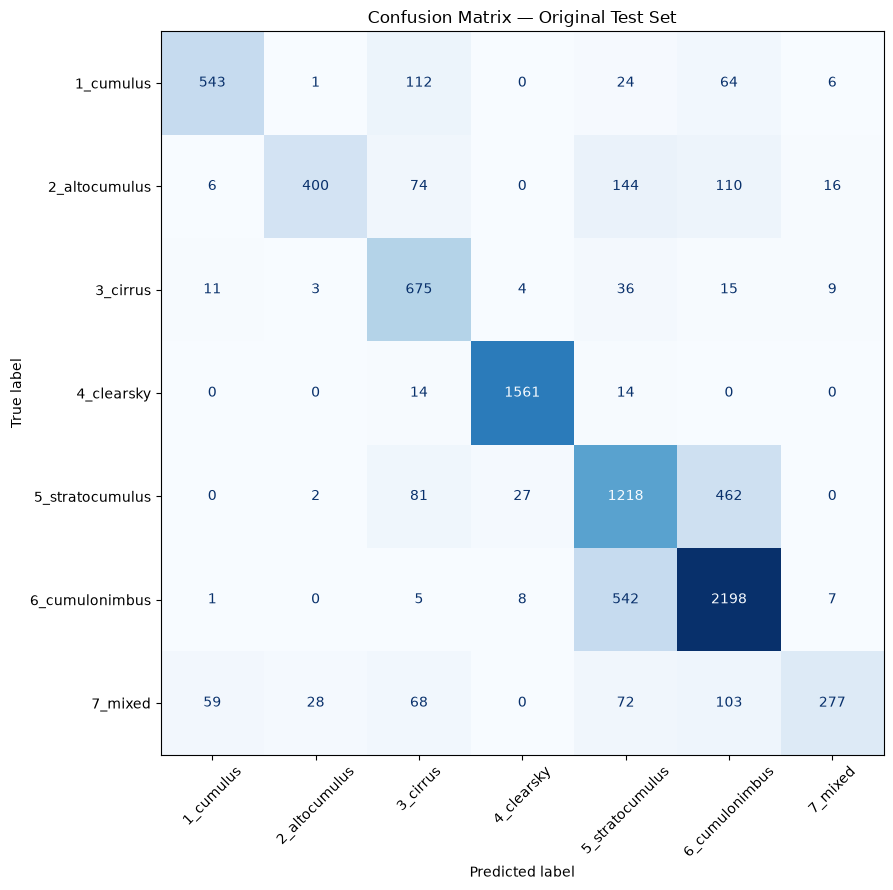

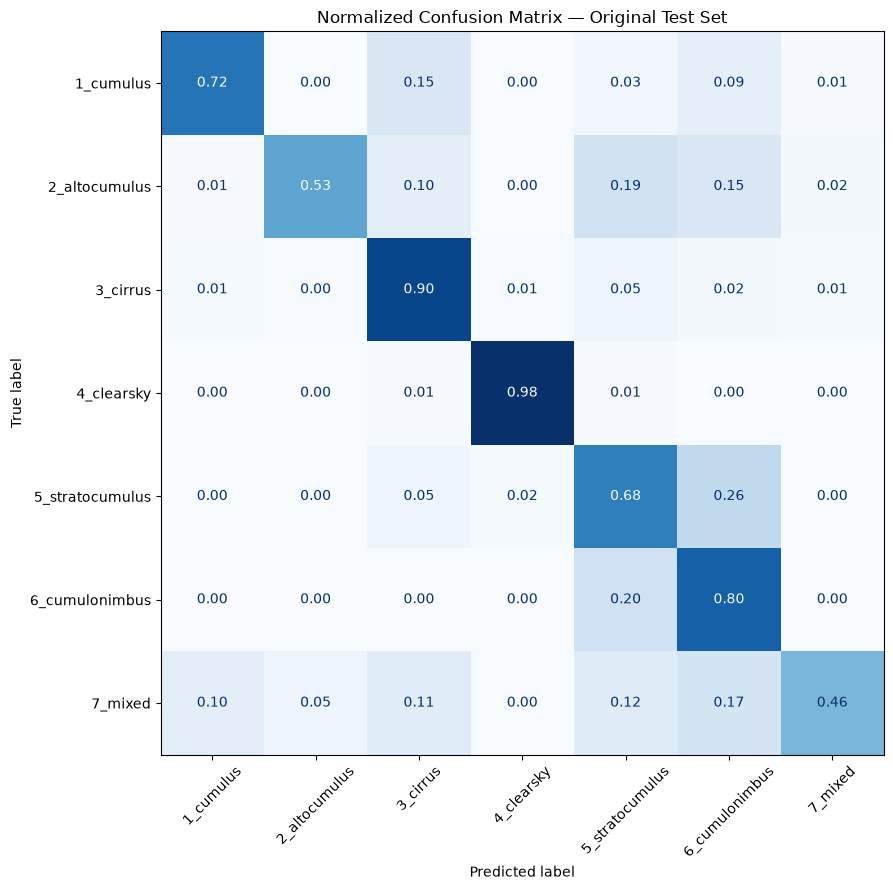

In [13]:
fig, axis = plt.subplots(figsize=(10, 9))  # Membuat area confusion matrix mentah.
raw_display = ConfusionMatrixDisplay(confusion_matrix=confusion_raw, display_labels=class_names)  # Membentuk visualisasi mentah.
raw_display.plot(ax=axis, cmap="Blues", values_format="d", colorbar=False)  # Menggambar confusion matrix mentah.
axis.set_title("Confusion Matrix — Original Test Set")  # Menentukan judul.
axis.tick_params(axis="x", rotation=45)  # Memutar label sumbu horizontal.
fig.tight_layout()  # Merapikan tata letak.
fig.savefig(CONFUSION_MATRIX_FIGURE_PATH, dpi=160, bbox_inches="tight")  # Menyimpan gambar.
plt.show()  # Menampilkan gambar.

fig, axis = plt.subplots(figsize=(10, 9))  # Membuat area confusion matrix normalisasi.
normalized_display = ConfusionMatrixDisplay(confusion_matrix=confusion_normalized, display_labels=class_names)  # Membentuk visualisasi normalisasi.
normalized_display.plot(ax=axis, cmap="Blues", values_format=".2f", colorbar=False)  # Menggambar confusion matrix normalisasi.
axis.set_title("Normalized Confusion Matrix — Original Test Set")  # Menentukan judul.
axis.tick_params(axis="x", rotation=45)  # Memutar label sumbu horizontal.
fig.tight_layout()  # Merapikan tata letak.
fig.savefig(NORMALIZED_CONFUSION_MATRIX_FIGURE_PATH, dpi=160, bbox_inches="tight")  # Menyimpan gambar.
plt.show()  # Menampilkan gambar.

## 8. Menyimpan Prediksi Test

Setiap hasil prediksi disimpan agar evaluasi dapat diaudit tanpa menjalankan test set kembali.

Prediksi salah diurutkan berdasarkan confidence tertinggi. Kesalahan dengan confidence tinggi menjadi prioritas dalam analisis kesalahan dan Grad-CAM.

In [14]:
relative_image_paths = [str(Path(path).relative_to(PROJECT_DIR)) for path, _ in test_dataset.samples]  # Mengambil path relatif citra.
true_class_names = [IDX_TO_CLASS[int(index)] for index in y_true]  # Mengubah label aktual menjadi nama kelas.
predicted_class_names = [IDX_TO_CLASS[int(index)] for index in y_pred]  # Mengubah prediksi menjadi nama kelas.
top_2_class_names = [[IDX_TO_CLASS[int(index)] for index in indices] for indices in top_2_indices]  # Mengubah top-2 menjadi nama kelas.

predictions_df = pd.DataFrame({  # Membentuk tabel prediksi.
    "image_path": relative_image_paths,  # Menyimpan lokasi citra.
    "true_class_id": y_true.astype(int),  # Menyimpan indeks aktual.
    "true_class_name": true_class_names,  # Menyimpan nama kelas aktual.
    "predicted_class_id": y_pred.astype(int),  # Menyimpan indeks prediksi.
    "predicted_class_name": predicted_class_names,  # Menyimpan nama kelas prediksi.
    "top_2_predictions": [" | ".join(names) for names in top_2_class_names],  # Menyimpan dua prediksi teratas.
    "confidence": prediction_confidence,  # Menyimpan confidence.
    "entropy": prediction_entropy,  # Menyimpan entropy.
    "is_correct": y_true == y_pred,  # Menyimpan status prediksi.
})  # Menutup pembuatan tabel.

for class_index, class_name in enumerate(class_names):  # Mengiterasi seluruh kelas.
    probability_column = f"probability_{class_name}"  # Membentuk nama kolom probabilitas.
    predictions_df[probability_column] = y_probability[:, class_index]  # Menyimpan probabilitas kelas.

misclassified_df = predictions_df.loc[~predictions_df["is_correct"]].copy()  # Mengambil prediksi salah.
misclassified_df = misclassified_df.sort_values("confidence", ascending=False)  # Mengurutkan berdasarkan confidence.

predictions_df.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8")  # Menyimpan seluruh prediksi.
misclassified_df.to_csv(MISCLASSIFIED_PATH, index=False, encoding="utf-8")  # Menyimpan prediksi salah.
report_df.to_csv(REPORT_PATH, encoding="utf-8")  # Menyimpan classification report.

print(f"Prediksi benar : {predictions_df['is_correct'].sum():,}")  # Menampilkan prediksi benar.
print(f"Prediksi salah : {len(misclassified_df):,}")  # Menampilkan prediksi salah.
print(f"Error rate     : {len(misclassified_df) / len(predictions_df):.4%}")  # Menampilkan error rate.

display(misclassified_df.head(20))  # Menampilkan 20 kesalahan confidence tertinggi.

Prediksi benar : 6,872
Prediksi salah : 2,128
Error rate     : 23.6444%


,image_path,true_class_id,true_class_name,predicted_class_id,predicted_class_name,top_2_predictions,confidence,entropy,is_correct,probability_1_cumulus,probability_2_altocumulus,probability_3_cirrus,probability_4_clearsky,probability_5_stratocumulus,probability_6_cumulonimbus,probability_7_mixed
7548,dataset\source\test\6_cumulonimbus\6_cumulonimbus_004920.jpg,5,6_cumulonimbus,6,7_mixed,7_mixed | 1_cumulus,0.986836,0.088141,False,0.006968,0.000808,0.002509,0.000518,0.000759,0.001601,0.986836
1206,dataset\source\test\2_altocumulus\2_altocumulus_001182.jpg,1,2_altocumulus,6,7_mixed,7_mixed | 2_altocumulus,0.982984,0.107988,False,0.003789,0.009469,0.000452,0.001546,0.000827,0.000934,0.982984
1219,dataset\source\test\2_altocumulus\2_altocumulus_001195.jpg,1,2_altocumulus,6,7_mixed,7_mixed | 2_altocumulus,0.972270,0.155554,False,0.003073,0.019124,0.001671,0.003008,0.000504,0.000350,0.972270
1213,dataset\source\test\2_altocumulus\2_altocumulus_001189.jpg,1,2_altocumulus,6,7_mixed,7_mixed | 2_altocumulus,0.970354,0.154538,False,0.000639,0.024387,0.002499,0.001204,0.000600,0.000316,0.970354
226,dataset\source\test\1_cumulus\1_cumulus_001002.jpg,0,1_cumulus,2,3_cirrus,3_cirrus | 7_mixed,0.962793,0.215149,False,0.009663,0.004868,0.962793,0.003472,0.004878,0.000295,0.014032
6229,dataset\source\test\6_cumulonimbus\6_cumulonimbus_003601.jpg,5,6_cumulonimbus,4,5_stratocumulus,5_stratocumulus | 6_cumulonimbus,0.947146,0.292317,False,0.008809,0.004499,0.008455,0.001549,0.947146,0.015190,0.014354
1209,dataset\source\test\2_altocumulus\2_altocumulus_001185.jpg,1,2_altocumulus,6,7_mixed,7_mixed | 2_altocumulus,0.946734,0.265473,False,0.002513,0.034283,0.000728,0.001404,0.003208,0.011130,0.946734
8465,dataset\source\test\7_mixed\7_mixed_000421.jpg,6,7_mixed,2,3_cirrus,3_cirrus | 7_mixed,0.942772,0.299152,False,0.012221,0.010251,0.942772,0.000777,0.008062,0.000843,0.025075
240,dataset\source\test\1_cumulus\1_cumulus_001016.jpg,0,1_cumulus,2,3_cirrus,3_cirrus | 7_mixed,0.939195,0.319965,False,0.015033,0.007574,0.939195,0.004224,0.006291,0.001810,0.025874
277,dataset\source\test\1_cumulus\1_cumulus_001053.jpg,0,1_cumulus,2,3_cirrus,3_cirrus | 7_mixed,0.932948,0.354331,False,0.012023,0.012023,0.932948,0.001982,0.009813,0.007627,0.023585


## 9. F1-Score Setiap Kelas

Grafik F1-score digunakan untuk menilai keseimbangan precision dan recall setiap kelas pada test set asli.

Perhatian utama diberikan kepada:

- kelas dengan F1-score terendah;
- kelas dengan support kecil;
- perbedaan F1-score validation dan test;
- kelas yang sering tertukar pada confusion matrix.

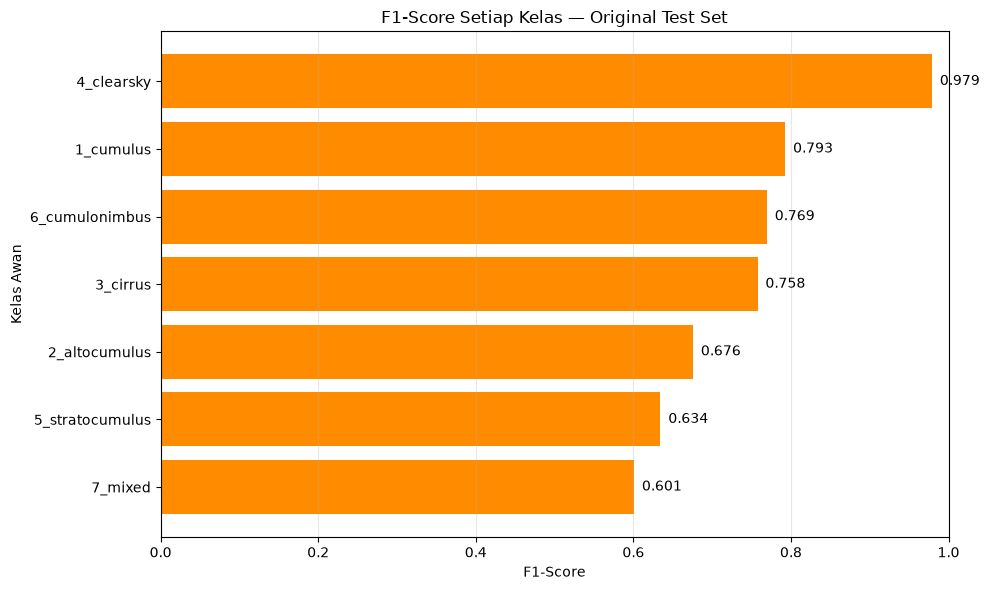

,class_name,precision,recall,f1-score,support
6,7_mixed,0.8794,0.4563,0.6009,607.0
4,5_stratocumulus,0.5941,0.6804,0.6344,1790.0
1,2_altocumulus,0.9217,0.5333,0.6757,750.0
2,3_cirrus,0.6560,0.8964,0.7576,753.0
5,6_cumulonimbus,0.7446,0.7961,0.7695,2761.0
0,1_cumulus,0.8758,0.7240,0.7927,750.0
3,4_clearsky,0.9756,0.9824,0.9790,1589.0


In [15]:
per_class_report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()  # Mengambil metrik setiap kelas.
per_class_report_df.index.name = "class_name"  # Memberikan nama indeks.
per_class_report_df = per_class_report_df.reset_index()  # Mengubah indeks menjadi kolom.
per_class_report_df = per_class_report_df.sort_values("f1-score", ascending=True)  # Mengurutkan F1 terendah.

fig, axis = plt.subplots(figsize=(10, 6))  # Membuat area grafik.
bars = axis.barh(  # Membuat diagram batang horizontal.
    per_class_report_df["class_name"],  # Menggunakan nama kelas.
    per_class_report_df["f1-score"],  # Menggunakan F1-score.
    color="darkorange",  # Menentukan warna batang test.
)  # Menutup diagram batang.

axis.set_title("F1-Score Setiap Kelas — Original Test Set")  # Menentukan judul.
axis.set_xlabel("F1-Score")  # Menentukan label horizontal.
axis.set_ylabel("Kelas Awan")  # Menentukan label vertikal.
axis.set_xlim(0.0, 1.0)  # Membatasi rentang F1.
axis.grid(axis="x", alpha=0.3)  # Menambahkan garis bantu.

for bar, value in zip(bars, per_class_report_df["f1-score"]):  # Mengiterasi batang.
    axis.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")  # Menambahkan nilai F1.

fig.tight_layout()  # Merapikan tata letak.
fig.savefig(PER_CLASS_F1_PATH, dpi=160, bbox_inches="tight")  # Menyimpan grafik.
plt.show()  # Menampilkan grafik.

display(per_class_report_df.round(4))  # Menampilkan metrik kelas.

## 10. Membandingkan Validation dan Test

Perbandingan validation dan test digunakan untuk mengukur generalization gap.

Generalization gap dihitung sebagai:

\[
\text{gap} = \text{test metric} - \text{validation metric}
\]

Nilai negatif menunjukkan performa test lebih rendah. Penurunan kecil masih wajar karena test set berasal dari data yang tidak digunakan dalam pemilihan checkpoint.

Perbandingan ini tidak digunakan untuk memilih ulang model.

In [16]:
validation_summary_candidates = list(  # Mencari ringkasan validation sebelumnya.
    LOGS_DIR.glob("resnet50_reference_tl_validation_*/validation_summary.json")  # Menggunakan pola folder validation.
)  # Menutup pencarian validation.

validation_comparison = None  # Menyiapkan hasil perbandingan.

if validation_summary_candidates:  # Memeriksa ketersediaan ringkasan validation.
    latest_validation_summary_path = max(  # Memilih ringkasan validation terbaru.
        validation_summary_candidates,  # Memberikan daftar kandidat.
        key=lambda path: path.stat().st_mtime,  # Membandingkan waktu modifikasi.
    )  # Menutup pemilihan ringkasan terbaru.

    with latest_validation_summary_path.open("r", encoding="utf-8") as file:  # Membuka ringkasan validation.
        validation_summary = json.load(file)  # Membaca ringkasan validation.

    validation_metrics = validation_summary["metrics"]  # Mengambil metrik validation.

    validation_comparison = {  # Membentuk perbandingan validation dan test.
        "validation_summary": str(latest_validation_summary_path.relative_to(PROJECT_DIR)),  # Menyimpan lokasi ringkasan validation.
        "validation_accuracy": float(validation_metrics["accuracy"]),  # Menyimpan validation accuracy.
        "test_accuracy": float(accuracy),  # Menyimpan test accuracy.
        "accuracy_gap": float(accuracy - validation_metrics["accuracy"]),  # Menghitung gap accuracy.
        "validation_macro_f1": float(validation_metrics["macro_f1"]),  # Menyimpan validation macro F1.
        "test_macro_f1": float(macro_f1),  # Menyimpan test macro F1.
        "macro_f1_gap": float(macro_f1 - validation_metrics["macro_f1"]),  # Menghitung gap macro F1.
    }  # Menutup perbandingan.

    comparison_table = pd.DataFrame({  # Membentuk tabel perbandingan.
        "Metrik": ["Accuracy", "Macro F1-score"],  # Menentukan metrik.
        "Validation": [validation_metrics["accuracy"], validation_metrics["macro_f1"]],  # Memasukkan hasil validation.
        "Test": [accuracy, macro_f1],  # Memasukkan hasil test.
        "Test - Validation": [  # Membentuk nilai gap.
            accuracy - validation_metrics["accuracy"],  # Memasukkan gap accuracy.
            macro_f1 - validation_metrics["macro_f1"],  # Memasukkan gap macro F1.
        ],  # Menutup daftar gap.
    })  # Menutup pembuatan tabel.

    display(comparison_table.style.format("{:.4%}"))  # Menampilkan tabel dalam format persentase.
else:  # Menangani kondisi ringkasan validation tidak ditemukan.
    print("Ringkasan validation tidak ditemukan. Perbandingan gap dilewati.")  # Menampilkan informasi.

ValueError: Unknown format code '%' for object of type 'str'

## 11. Menyimpan Ringkasan Pengujian

Ringkasan test menyimpan:

- identitas checkpoint;
- SHA-256 checkpoint;
- jumlah citra test;
- metrik global;
- hasil perbandingan validation dan test;
- lokasi seluruh artefak;
- status bahwa test set telah digunakan.

Setelah ringkasan tersimpan, eksperimen ini dianggap telah menggunakan test set.

In [17]:
test_summary = {  # Membentuk ringkasan pengujian.
    "created_at": datetime.now().astimezone().isoformat(timespec="seconds"),  # Menyimpan waktu pengujian.
    "run_id": RUN_ID,  # Menyimpan identitas pengujian.
    "stage": "10b_pengujian_model_reference_tl",  # Menyimpan nama tahap.
    "test_policy": "original_test_only",  # Menyimpan kebijakan test.
    "model_name": MODEL_NAME,  # Menyimpan nama model.
    "checkpoint": str(BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi checkpoint.
    "checkpoint_sha256": CHECKPOINT_SHA256,  # Menyimpan SHA-256 checkpoint.
    "checkpoint_phase": checkpoint.get("phase"),  # Menyimpan fase checkpoint.
    "checkpoint_global_epoch": checkpoint.get("global_epoch"),  # Menyimpan epoch checkpoint.
    "num_classes": NUM_CLASSES,  # Menyimpan jumlah kelas.
    "class_to_idx": CLASS_TO_IDX,  # Menyimpan mapping kelas.
    "input_shape": [INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH],  # Menyimpan bentuk input.
    "test_samples": int(len(test_dataset)),  # Menyimpan jumlah citra test.
    "batch_size": BATCH_SIZE,  # Menyimpan batch size.
    "device": str(DEVICE),  # Menyimpan device.
    "mixed_precision": AMP_ENABLED,  # Menyimpan status mixed precision.
    "metrics": test_metrics,  # Menyimpan metrik test.
    "validation_comparison": validation_comparison,  # Menyimpan perbandingan validation.
    "misclassified_samples": int(len(misclassified_df)),  # Menyimpan jumlah kesalahan.
    "model_parameters_updated": False,  # Menandai parameter model tidak diperbarui.
    "output_artifacts": {  # Menyimpan lokasi artefak.
        "predictions": str(PREDICTIONS_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi prediksi.
        "misclassified": str(MISCLASSIFIED_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi kesalahan.
        "classification_report": str(REPORT_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi report.
        "confusion_matrix": str(CONFUSION_MATRIX_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi confusion matrix.
        "normalized_confusion_matrix": str(NORMALIZED_CONFUSION_MATRIX_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi normalisasi.
        "error_pairs": str(ERROR_PAIRS_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi pasangan kesalahan.
        "confusion_matrix_figure": str(CONFUSION_MATRIX_FIGURE_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi gambar.
        "per_class_f1_figure": str(PER_CLASS_F1_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi grafik F1.
    },  # Menutup daftar artefak.
    "test_data_used": True,  # Menandai test set telah digunakan pada tahap ini.
}  # Menutup ringkasan test.

with SUMMARY_PATH.open("w", encoding="utf-8") as file:  # Membuka file ringkasan.
    json.dump(test_summary, file, indent=2, ensure_ascii=False)  # Menyimpan ringkasan JSON.

print(f"Ringkasan test: {SUMMARY_PATH.relative_to(PROJECT_DIR)}")  # Menampilkan lokasi ringkasan.

Ringkasan test: logs\resnet50_reference_tl_test_20260828_141732\test_summary.json


## 12. Pemeriksaan Akhir Pengujian

Pemeriksaan akhir memastikan:

- seluruh citra test diproses;
- seluruh kelas tersedia;
- probabilitas valid;
- checkpoint tidak pernah menggunakan test selama training;
- parameter model tidak diperbarui;
- seluruh artefak utama berhasil disimpan.

In [18]:
observed_classes = set(np.unique(y_true).tolist())  # Mengambil kelas yang ditemukan.
expected_classes = set(range(NUM_CLASSES))  # Membentuk kelas yang diharapkan.

final_checks = {  # Membentuk pemeriksaan akhir.
    "Seluruh sampel test diproses": len(y_true) == len(test_dataset),  # Memeriksa jumlah hasil.
    "Seluruh kelas test tersedia": observed_classes == expected_classes,  # Memeriksa kelengkapan kelas.
    "Probabilitas finite": np.isfinite(y_probability).all(),  # Memeriksa probabilitas.
    "Jumlah probabilitas valid": np.allclose(y_probability.sum(axis=1), 1.0, atol=1e-5),  # Memeriksa jumlah probabilitas.
    "Test loss finite": np.isfinite(test_loss),  # Memeriksa test loss.
    "Accuracy valid": 0.0 <= accuracy <= 1.0,  # Memeriksa accuracy.
    "Macro F1 valid": 0.0 <= macro_f1 <= 1.0,  # Memeriksa macro F1.
    "Checkpoint bebas test saat training": checkpoint.get("test_data_used") is False,  # Memeriksa checkpoint.
    "Model tidak diperbarui": test_summary["model_parameters_updated"] is False,  # Memeriksa pembaruan model.
    "Predictions tersedia": PREDICTIONS_PATH.is_file(),  # Memeriksa prediksi.
    "Classification report tersedia": REPORT_PATH.is_file(),  # Memeriksa report.
    "Confusion matrix tersedia": CONFUSION_MATRIX_PATH.is_file(),  # Memeriksa confusion matrix.
    "Error pairs tersedia": ERROR_PAIRS_PATH.is_file(),  # Memeriksa pasangan kesalahan.
    "Ringkasan test tersedia": SUMMARY_PATH.is_file(),  # Memeriksa ringkasan.
    "Test ditandai telah digunakan": test_summary["test_data_used"] is True,  # Memeriksa status penggunaan test.
}  # Menutup pemeriksaan.

final_check_table = pd.DataFrame({  # Membentuk tabel pemeriksaan.
    "Pemeriksaan": list(final_checks.keys()),  # Memasukkan nama pemeriksaan.
    "Status": ["Berhasil" if status else "Gagal" for status in final_checks.values()],  # Mengubah status.
})  # Menutup pembuatan tabel.

display(final_check_table)  # Menampilkan pemeriksaan.

failed_checks = [name for name, status in final_checks.items() if not status]  # Mengambil pemeriksaan gagal.

if failed_checks:  # Memeriksa kegagalan.
    failed_text = "\n".join(f"- {name}" for name in failed_checks)  # Menyusun daftar kegagalan.
    raise AssertionError(f"Pemeriksaan akhir gagal:\n{failed_text}")  # Menghentikan notebook jika gagal.

print("=" * 78)  # Menampilkan garis pembatas.
print("PENGUJIAN AKHIR MODEL TRANSFER LEARNING SELESAI")  # Menampilkan status penyelesaian.
print("=" * 78)  # Menampilkan garis pembatas.
print(f"Model                    : {MODEL_NAME}")  # Menampilkan model.
print(f"Checkpoint epoch         : {checkpoint.get('global_epoch')}")  # Menampilkan epoch.
print(f"Jumlah test              : {len(test_dataset):,}")  # Menampilkan jumlah test.
print(f"Test loss                : {test_loss:.6f}")  # Menampilkan test loss.
print(f"Accuracy                 : {accuracy:.4%}")  # Menampilkan accuracy.
print(f"Balanced accuracy        : {balanced_accuracy:.4%}")  # Menampilkan balanced accuracy.
print(f"Macro precision          : {macro_precision:.4%}")  # Menampilkan macro precision.
print(f"Macro recall             : {macro_recall:.4%}")  # Menampilkan macro recall.
print(f"Macro F1-score           : {macro_f1:.4%}")  # Menampilkan macro F1.
print(f"Weighted F1-score        : {weighted_f1:.4%}")  # Menampilkan weighted F1.
print(f"Cohen's kappa            : {cohen_kappa:.4f}")  # Menampilkan kappa.
print(f"Top-2 accuracy           : {top_2_accuracy:.4%}")  # Menampilkan top-2 accuracy.
print(f"ROC-AUC macro OVR        : {roc_auc_macro_ovr}")  # Menampilkan ROC-AUC.
print(f"Jumlah kesalahan         : {len(misclassified_df):,}")  # Menampilkan kesalahan.
print("Parameter model berubah  : Tidak")  # Menegaskan model tidak berubah.
print("Test set telah digunakan : Ya")  # Menandai test telah digunakan.
print(f"Folder hasil             : {RUN_LOG_DIR.relative_to(PROJECT_DIR)}")  # Menampilkan folder hasil.
print("=" * 78)  # Menampilkan garis penutup.

,Pemeriksaan,Status
0,Seluruh sampel test diproses,Berhasil
1,Seluruh kelas test tersedia,Berhasil
2,Probabilitas finite,Berhasil
3,Jumlah probabilitas valid,Berhasil
4,Test loss finite,Berhasil
5,Accuracy valid,Berhasil
6,Macro F1 valid,Berhasil
7,Checkpoint bebas test saat training,Berhasil
8,Model tidak diperbarui,Berhasil
9,Predictions tersedia,Berhasil


PENGUJIAN AKHIR MODEL TRANSFER LEARNING SELESAI
Model                    : resnet50
Checkpoint epoch         : 21
Jumlah test              : 9,000
Test loss                : 1.277702
Accuracy                 : 76.3556%
Balanced accuracy        : 72.4144%
Macro precision          : 80.6737%
Macro recall             : 72.4144%
Macro F1-score           : 74.4237%
Weighted F1-score        : 76.1347%
Cohen's kappa            : 0.7048
Top-2 accuracy           : 90.6778%
ROC-AUC macro OVR        : 0.9333527636701727
Jumlah kesalahan         : 2,128
Parameter model berubah  : Tidak
Test set telah digunakan : Ya
Folder hasil             : logs\resnet50_reference_tl_test_20260828_141732


## Kesimpulan

Notebook ini melakukan pengujian akhir model ResNet50 transfer learning menggunakan test set asli GCD.

Checkpoint ditetapkan sebelum test set digunakan:

```text
models/resnet50_gcd_reference_tl_best.pth